
# FPGA-only Conv2D Batch Performance — 20 Images

This notebook is based on the latest FPGA-only Conv2D performance notebook.

It is configured for the project test where the input images are stored in a folder named `input` in the same directory as this notebook.

Expected folder structure on the PYNQ board:

```text
2_eissa/
├── conv2d_pynq_overlay.bit
├── conv2d_pynq_overlay.hwh
├── fpga_only_conv2d_performance_batch_20_assignment.ipynb
└── input/
    ├── 01.jpg / 01.png / 01
    ├── 02.jpg / 02.png / 02
    ├── ...
    └── 20.jpg / 20.png / 20
```

The notebook does not resize the images. It checks that every input image is already `640 × 640`.

The notebook has separate execution cells for:

1. Blur 5×5 batch results
2. Edge-emphasis 5×5 batch results
3. Final combined statistics and project-level summary


In [1]:
from pynq import PL

PL.reset()
print("PYNQ PL state reset. Now run the benchmark cell again.")

PYNQ PL state reset. Now run the benchmark cell again.


In [ ]:

from __future__ import annotations

import csv
import os
import platform
import sys
import time
import traceback
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple, Any

import numpy as np
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import display, Image as IPythonImage
    IPYTHON_DISPLAY_AVAILABLE = True
except Exception:
    IPYTHON_DISPLAY_AVAILABLE = False

try:
    from PIL import Image
    PIL_AVAILABLE = True
except Exception:
    PIL_AVAILABLE = False

try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    psutil = None
    PSUTIL_AVAILABLE = False

try:
    from pynq import Overlay, allocate
    PYNQ_AVAILABLE = True
    PYNQ_IMPORT_ERROR = ""
except Exception as exc:
    Overlay = None
    allocate = None
    PYNQ_AVAILABLE = False
    PYNQ_IMPORT_ERROR = str(exc)

# =============================================================================
# Configuration
# =============================================================================

OVERLAY_BIT_FILENAME = "conv2d_pynq_overlay.bit"
OUTPUT_DIR = "fpga_only_outputs"
INPUT_DIR_NAME = "input"

EXPECTED_IMAGE_SIZE = (640, 640)       # width, height
EXPECTED_IMAGE_COUNT = 20
INPUT_IMAGE_STEMS = [f"{i:02d}" for i in range(1, EXPECTED_IMAGE_COUNT + 1)]
INPUT_EXTENSIONS = ["", ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]


FPGA_WARMUP_RUNS = 1

SAVE_IMAGES = True
SAVE_FIRST_N_OUTPUT_IMAGES = 20        
PRINT_REGISTER_MAP = False

MAX_HEIGHT = 1080
MAX_WIDTH = 1920

# Energy handling:

MANUAL_POWER_WATTS = None             

print("Environment")
print("-----------")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PYNQ available:", PYNQ_AVAILABLE)
if not PYNQ_AVAILABLE:
    print("PYNQ import note:", PYNQ_IMPORT_ERROR)
    print("This notebook must be run on the PYNQ-Z2 board for FPGA execution.")

print("\nConfiguration")
print("-------------")
print("Overlay:", OVERLAY_BIT_FILENAME)
print("Input folder:", INPUT_DIR_NAME)
print("Expected image size:", EXPECTED_IMAGE_SIZE)
print("Expected image count:", EXPECTED_IMAGE_COUNT)
print("Warmups per kernel:", FPGA_WARMUP_RUNS)
print("Manual power watts:", MANUAL_POWER_WATTS)


Environment
-----------
Python: 3.10.4
Platform: Linux-6.6.10-xilinx-v2024.1-gb36799f4e960-armv7l-with-glibc2.35
PYNQ available: True

Configuration
-------------
Overlay: conv2d_pynq_overlay.bit
Input folder: input
Expected image size: (640, 640)
Expected image count: 20
Warmups per kernel: 1
Manual power watts: None


In [ ]:

# Utility helpers and system sensors
# --------------------------------------------

def notebook_folder() -> Path:
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd().resolve()


def format_duration(seconds: float) -> str:
    total = int(round(max(0.0, seconds)))
    h = total // 3600
    m = (total % 3600) // 60
    s = total % 60
    if h:
        return f"{h}h {m:02d}m {s:02d}s"
    if m:
        return f"{m}m {s:02d}s"
    return f"{s}s"


def summarize_values(values: Sequence[float]) -> Dict[str, float]:
    arr = np.asarray(values, dtype=np.float64)
    if arr.size == 0:
        return {
            "mean": float("nan"),
            "median": float("nan"),
            "std": float("nan"),
            "min": float("nan"),
            "max": float("nan"),
            "sum": float("nan"),
        }
    return {
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "sum": float(np.sum(arr)),
    }


def save_uint8_image(path: Path, arr: np.ndarray) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if PIL_AVAILABLE:
        Image.fromarray(arr.astype(np.uint8), mode="L").save(path)
    else:
        plt.imsave(path, arr.astype(np.uint8), cmap="gray", vmin=0, vmax=255)


def _read_proc_meminfo() -> Dict[str, float]:
    values: Dict[str, float] = {}
    try:
        with open("/proc/meminfo", "r", encoding="utf-8") as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 2:
                    values[parts[0].rstrip(":")] = float(parts[1]) * 1024.0
    except Exception:
        pass
    return values


def read_temperatures_c() -> Dict[str, float]:
    temps: Dict[str, float] = {}

    # Common Linux thermal zones.
    for p in Path("/sys/class/thermal").glob("thermal_zone*/temp"):
        try:
            zone = p.parent.name
            type_path = p.parent / "type"
            label = type_path.read_text(errors="ignore").strip() if type_path.exists() else zone
            raw = float(p.read_text().strip())
            temp_c = raw / 1000.0 if raw > 1000 else raw
            temps[label] = temp_c
        except Exception:
            pass

    # hwmon temperature inputs.
    for p in Path("/sys/class/hwmon").glob("hwmon*/temp*_input"):
        try:
            label = p.parent.name + "_" + p.stem
            raw = float(p.read_text().strip())
            temp_c = raw / 1000.0 if raw > 1000 else raw
            temps[label] = temp_c
        except Exception:
            pass

    return temps


def read_power_watts() -> Dict[str, float]:

    powers: Dict[str, float] = {}

    # Direct power input in microwatts, milliwatts, or watts depending on driver.
    for p in Path("/sys/class/hwmon").glob("hwmon*/power*_input"):
        try:
            label = p.parent.name + "_" + p.stem
            raw = float(p.read_text().strip())
            if raw > 100000:
                watts = raw / 1_000_000.0
            elif raw > 1000:
                watts = raw / 1000.0
            else:
                watts = raw
            powers[label] = watts
        except Exception:
            pass

    # Some IIO power monitors expose voltage/current only.
    for dev in Path("/sys/bus/iio/devices").glob("iio:device*"):
        try:
            name_path = dev / "name"
            dev_name = name_path.read_text(errors="ignore").strip() if name_path.exists() else dev.name
            voltage_files = list(dev.glob("in_voltage*_input"))
            current_files = list(dev.glob("in_current*_input"))
            for vf in voltage_files:
                suffix = vf.name.replace("in_voltage", "").replace("_input", "")
                cf = dev / f"in_current{suffix}_input"
                if not cf.exists() and current_files:
                    cf = current_files[0]
                if cf.exists():
                    v_raw = float(vf.read_text().strip())
                    c_raw = float(cf.read_text().strip())

                    # Common convention: voltage in mV and current in mA.
                    volts = v_raw / 1000.0 if v_raw > 100 else v_raw
                    amps = c_raw / 1000.0 if c_raw > 10 else c_raw
                    powers[f"{dev_name}_ch{suffix}"] = volts * amps
        except Exception:
            pass

    if not powers and MANUAL_POWER_WATTS is not None:
        powers["manual_power_watts"] = float(MANUAL_POWER_WATTS)

    return powers


def system_snapshot(label: str) -> Dict[str, Any]:
    snap: Dict[str, Any] = {
        "label": label,
        "timestamp_s": time.time(),
        "cpu_percent": float("nan"),
        "ram_used_mb": float("nan"),
        "ram_total_mb": float("nan"),
        "ram_percent": float("nan"),
        "process_rss_mb": float("nan"),
        "loadavg_1min": float("nan"),
        "temperatures_c": read_temperatures_c(),
        "power_watts": read_power_watts(),
    }

    if PSUTIL_AVAILABLE:
        try:
            snap["cpu_percent"] = float(psutil.cpu_percent(interval=0.1))
            vm = psutil.virtual_memory()
            snap["ram_used_mb"] = float(vm.used) / (1024.0 * 1024.0)
            snap["ram_total_mb"] = float(vm.total) / (1024.0 * 1024.0)
            snap["ram_percent"] = float(vm.percent)
            snap["process_rss_mb"] = float(psutil.Process(os.getpid()).memory_info().rss) / (1024.0 * 1024.0)
        except Exception:
            pass
    else:
        meminfo = _read_proc_meminfo()
        if "MemTotal" in meminfo and "MemAvailable" in meminfo:
            total = meminfo["MemTotal"]
            used = total - meminfo["MemAvailable"]
            snap["ram_total_mb"] = total / (1024.0 * 1024.0)
            snap["ram_used_mb"] = used / (1024.0 * 1024.0)
            snap["ram_percent"] = 100.0 * used / total if total > 0 else float("nan")
        try:
            with open("/proc/self/statm", "r", encoding="utf-8") as f:
                pages = int(f.read().split()[1])
                snap["process_rss_mb"] = pages * os.sysconf("SC_PAGE_SIZE") / (1024.0 * 1024.0)
        except Exception:
            pass

    try:
        snap["loadavg_1min"] = float(os.getloadavg()[0])
    except Exception:
        pass

    return snap


def primary_temperature(snapshot: Dict[str, Any]) -> float:
    temps = snapshot.get("temperatures_c", {})
    if not temps:
        return float("nan")
    # Return highest observed board/SoC temperature as a conservative single value.
    return float(max(temps.values()))


def total_power_watts(snapshot: Dict[str, Any]) -> float:
    powers = snapshot.get("power_watts", {})
    if not powers:
        return float("nan")
    return float(sum(powers.values()))


def energy_joules(power_watts: float, seconds: float) -> float:
    if not np.isfinite(power_watts):
        return float("nan")
    return float(power_watts * seconds)


def print_system_snapshot(snap: Dict[str, Any]) -> None:
    temp = primary_temperature(snap)
    power = total_power_watts(snap)

    print(
        f"{snap['label']}: "
        f"CPU={snap['cpu_percent']:.1f}% | "
        f"RAM={snap['ram_used_mb']:.1f}/{snap['ram_total_mb']:.1f} MB "
        f"({snap['ram_percent']:.1f}%) | "
        f"Process={snap['process_rss_mb']:.1f} MB | "
        f"Load1={snap['loadavg_1min']:.2f} | "
        f"Temp={temp:.1f} C | "
        f"Power={power:.3f} W"
    )

    if not snap.get("power_watts"):
        print("  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.")


In [ ]:

# Kernels and image loading
# ----------------------------------------------

KERNEL_REGISTER_NAMES = [
    "k00", "k01", "k02", "k03", "k04",
    "k10", "k11", "k12", "k13", "k14",
    "k20", "k21", "k22", "k23", "k24",
    "k30", "k31", "k32", "k33", "k34",
    "k40", "k41", "k42", "k43", "k44",
]

KERNELS: Dict[str, Dict[str, object]] = {
    "blur5x5": {
        "display": "Blur 5x5",
        "kernel": np.ones((5, 5), dtype=np.int16),
        "divisor": 25,
        "bias": 0,
    },
    "edge_emphasis5x5": {
        "display": "Edge emphasis 5x5",
        "kernel": np.array(
            [
                [-1, -1, -1, -1, -1],
                [-1, 1, 1, 1, -1],
                [-1, 1, 16, 1, -1],
                [-1, 1, 1, 1, -1],
                [-1, -1, -1, -1, -1],
            ],
            dtype=np.int16,
        ),
        "divisor": 1,
        "bias": 0,
    },
}


def find_image_by_stem(input_dir: Path, stem: str) -> Path:
    for ext in INPUT_EXTENSIONS:
        p = input_dir / f"{stem}{ext}"
        if p.exists() and p.is_file():
            return p
    raise FileNotFoundError(
        f"Missing image '{stem}' in {input_dir}. "
        f"Checked extensions: {INPUT_EXTENSIONS}"
    )


def load_input_batch(folder: Path) -> List[Tuple[str, Path, np.ndarray]]:
    if not PIL_AVAILABLE:
        raise RuntimeError("Pillow/PIL is required to load the input image folder.")

    input_dir = folder / INPUT_DIR_NAME
    if not input_dir.exists():
        raise FileNotFoundError(f"Input folder not found: {input_dir}")

    expected_w, expected_h = EXPECTED_IMAGE_SIZE
    loaded: List[Tuple[str, Path, np.ndarray]] = []

    for stem in INPUT_IMAGE_STEMS:
        path = find_image_by_stem(input_dir, stem)
        img_pil = Image.open(path).convert("L")
        width, height = img_pil.size

        if (width, height) != (expected_w, expected_h):
            raise ValueError(
                f"Image {path.name} has size {width}x{height}, "
                f"but expected {expected_w}x{expected_h}. "
                "This notebook does not resize batch images."
            )

        arr = np.asarray(img_pil, dtype=np.uint8)
        loaded.append((stem, path, arr))

    print(f"Loaded {len(loaded)} images from {input_dir}")
    print("First image:", loaded[0][1].name, loaded[0][2].shape, loaded[0][2].dtype)
    print("Last image:", loaded[-1][1].name, loaded[-1][2].shape, loaded[-1][2].dtype)

    return loaded


In [ ]:

# PYNQ overlay and register helpers
# ---------------------------------------------

def find_conv2d_ip(overlay) -> Tuple[object, str, Dict[str, object]]:
    candidates: List[str] = []

    for key, meta in overlay.ip_dict.items():
        key_l = key.lower()
        vlnv_l = str(meta.get("type", "")).lower()
        if "conv2d" in key_l or "conv2d" in vlnv_l:
            candidates.append(key)

    preferred = ["conv2d_accel_0", "conv2d_accel"] + candidates

    for name in preferred:
        if name in overlay.ip_dict:
            return getattr(overlay, name), name, overlay.ip_dict[name]
        if hasattr(overlay, name):
            return getattr(overlay, name), name, overlay.ip_dict.get(name, {})

    print("Available IPs:")
    for key, meta in overlay.ip_dict.items():
        print(f"  {key}: {meta.get('type', '')}")

    raise RuntimeError("Could not find the Conv2D HLS IP in the overlay.")


def load_overlay_and_ip(folder: Path):
    if not PYNQ_AVAILABLE:
        raise RuntimeError("PYNQ is not available. Run this notebook on the PYNQ-Z2 board.")

    bit_path = folder / OVERLAY_BIT_FILENAME
    hwh_path = bit_path.with_suffix(".hwh")

    print("\nOverlay files")
    print("BIT:", bit_path)
    print("HWH:", hwh_path)

    if not bit_path.exists():
        raise FileNotFoundError(f"Missing bitstream file: {bit_path}")
    if not hwh_path.exists():
        raise FileNotFoundError(f"Missing hardware handoff file: {hwh_path}")

    print("Loading overlay...")
    overlay = Overlay(str(bit_path))
    ip, ip_name, ip_meta = find_conv2d_ip(overlay)

    regs = ip_meta.get("registers", {})
    print("Overlay loaded.")
    print("Detected IP:", ip_name)
    print("Register names:", list(regs.keys()))

    if PRINT_REGISTER_MAP:
        try:
            print("\nRegister map:")
            print(ip.register_map)
        except Exception as exc:
            print("Could not print register map:", exc)

    return overlay, ip, ip_name, ip_meta


def configure_conv2d_ip(
    ip: object,
    ip_meta: Dict[str, object],
    in_phys_addr: int,
    out_phys_addr: int,
    rows: int,
    cols: int,
    kernel: np.ndarray,
    divisor: int,
    bias: int,
) -> None:
    regs = ip_meta.get("registers", {})
    if not regs:
        raise RuntimeError(
            "No register metadata found for conv2d_accel. "
            "Check that the .hwh file matches the .bit file."
        )

    def reg_offset(name: str) -> int:
        if name not in regs:
            raise KeyError(f"Register '{name}' not found. Available registers: {list(regs.keys())}")
        return int(regs[name]["address_offset"])

    def write_reg(name: str, value: int) -> None:
        ip.write(reg_offset(name), int(value) & 0xFFFFFFFF)

    write_reg("img_in_1", int(in_phys_addr) & 0xFFFFFFFF)
    write_reg("img_in_2", (int(in_phys_addr) >> 32) & 0xFFFFFFFF)
    write_reg("img_out_1", int(out_phys_addr) & 0xFFFFFFFF)
    write_reg("img_out_2", (int(out_phys_addr) >> 32) & 0xFFFFFFFF)

    write_reg("rows", int(rows))
    write_reg("cols", int(cols))
    write_reg("divisor", int(divisor))
    write_reg("bias", int(bias))

    flat = kernel.astype(np.int16).reshape(-1)
    for reg_name, coeff in zip(KERNEL_REGISTER_NAMES, flat):
        write_reg(reg_name, int(np.int16(coeff)))


def run_fpga_once(
    ip: object,
    ip_meta: Dict[str, object],
    img: np.ndarray,
    kernel: np.ndarray,
    divisor: int,
    bias: int,
) -> Tuple[np.ndarray, float, float]:
    rows, cols = img.shape

    in_buf = allocate(shape=(rows, cols), dtype=np.uint8)
    out_buf = allocate(shape=(rows, cols), dtype=np.uint8)

    try:
        in_buf[:, :] = img
        out_buf[:, :] = 0

        t_total0 = time.perf_counter()

        configure_conv2d_ip(
            ip=ip,
            ip_meta=ip_meta,
            in_phys_addr=int(in_buf.physical_address),
            out_phys_addr=int(out_buf.physical_address),
            rows=rows,
            cols=cols,
            kernel=kernel,
            divisor=divisor,
            bias=bias,
        )

        in_buf.flush()
        out_buf.flush()

        t_kernel0 = time.perf_counter()
        ip.write(0x00, 0x01)

        timeout_s = 20.0
        while (ip.read(0x00) & 0x2) == 0:
            if time.perf_counter() - t_kernel0 > timeout_s:
                raise TimeoutError("FPGA did not finish within timeout.")
            pass

        t_kernel1 = time.perf_counter()

        out_buf.invalidate()
        fpga_out = np.array(out_buf, dtype=np.uint8)

        t_total1 = time.perf_counter()

        return fpga_out, (t_kernel1 - t_kernel0) * 1000.0, (t_total1 - t_total0) * 1000.0

    finally:
        try:
            in_buf.freebuffer()
        except Exception:
            pass
        try:
            out_buf.freebuffer()
        except Exception:
            pass


In [ ]:

# Batch execution helpers
# ------------------------------------------------

ALL_BATCH_RESULTS: Dict[str, Dict[str, Any]] = {}


def run_kernel_on_batch(kernel_key: str) -> Dict[str, Any]:
    if not PYNQ_AVAILABLE:
        raise RuntimeError("PYNQ is not available. Run this notebook on the PYNQ-Z2 board.")

    if kernel_key not in KERNELS:
        raise ValueError(f"Unknown kernel: {kernel_key}. Available kernels: {list(KERNELS.keys())}")

    folder = notebook_folder()
    out_dir = folder / OUTPUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)

    batch = load_input_batch(folder)

    cfg = KERNELS[kernel_key]
    kernel = cfg["kernel"]
    divisor = int(cfg["divisor"])
    bias = int(cfg["bias"])
    display_name = str(cfg["display"])

    kernel_output_dir = out_dir / kernel_key
    kernel_output_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print(f"FPGA batch run: {display_name}")
    print("=" * 100)
    print("Images:", len(batch))
    print("Image size:", f"{EXPECTED_IMAGE_SIZE[0]}x{EXPECTED_IMAGE_SIZE[1]}")
    print("Output folder:", kernel_output_dir)

    overlay, ip, ip_name, ip_meta = load_overlay_and_ip(folder)
    print("Using IP:", ip_name)

    before = system_snapshot(f"before_{kernel_key}")
    print_system_snapshot(before)

    # Warmup using the first image.
    print("\nWarmup")
    for i in range(FPGA_WARMUP_RUNS):
        _, warm_kernel_ms, warm_total_ms = run_fpga_once(ip, ip_meta, batch[0][2], kernel, divisor, bias)
        print(f"  Warmup {i + 1}/{FPGA_WARMUP_RUNS}: kernel={warm_kernel_ms:.3f} ms, total={warm_total_ms:.3f} ms")

    per_image_rows: List[Dict[str, Any]] = []
    kernel_times_ms: List[float] = []
    total_times_ms: List[float] = []

    batch_wall_start = time.perf_counter()

    print("\nMeasured batch processing")
    for idx, (stem, path, img) in enumerate(batch, start=1):
        fpga_out, kernel_ms, total_ms = run_fpga_once(ip, ip_meta, img, kernel, divisor, bias)

        kernel_times_ms.append(kernel_ms)
        total_times_ms.append(total_ms)

        if SAVE_IMAGES and idx <= SAVE_FIRST_N_OUTPUT_IMAGES:
            save_uint8_image(kernel_output_dir / f"{stem}_{kernel_key}_fpga.png", fpga_out)

        out_min = int(fpga_out.min())
        out_max = int(fpga_out.max())
        out_mean = float(fpga_out.mean())

        row = {
            "image_id": stem,
            "image_file": path.name,
            "kernel_key": kernel_key,
            "kernel_display": display_name,
            "rows": int(img.shape[0]),
            "cols": int(img.shape[1]),
            "pixels": int(img.size),
            "fpga_kernel_ms": float(kernel_ms),
            "fpga_total_ms": float(total_ms),
            "output_min": out_min,
            "output_max": out_max,
            "output_mean": out_mean,
            "output_all_zero": bool(out_max == 0),
        }
        per_image_rows.append(row)

        print(
            f"  {idx:02d}/{len(batch)} {path.name}: "
            f"kernel={kernel_ms:.3f} ms, total={total_ms:.3f} ms, "
            f"out min/max/mean={out_min}/{out_max}/{out_mean:.2f}"
        )

    batch_wall_s = time.perf_counter() - batch_wall_start

    after = system_snapshot(f"after_{kernel_key}")
    print_system_snapshot(after)

    kernel_stats = summarize_values(kernel_times_ms)
    total_stats = summarize_values(total_times_ms)

    total_pixels = int(sum(row["pixels"] for row in per_image_rows))
    total_kernel_s = kernel_stats["sum"] / 1000.0
    total_end_to_end_s = total_stats["sum"] / 1000.0

    kernel_mpix_s = total_pixels / total_kernel_s / 1_000_000.0 if total_kernel_s > 0 else float("nan")
    total_mpix_s = total_pixels / total_end_to_end_s / 1_000_000.0 if total_end_to_end_s > 0 else float("nan")

    power_before_w = total_power_watts(before)
    power_after_w = total_power_watts(after)
    avg_power_w = float(np.nanmean([power_before_w, power_after_w])) if np.isfinite(power_before_w) or np.isfinite(power_after_w) else float("nan")

    energy_kernel_j = energy_joules(avg_power_w, total_kernel_s)
    energy_total_j = energy_joules(avg_power_w, total_end_to_end_s)
    energy_wall_j = energy_joules(avg_power_w, batch_wall_s)

    result = {
        "kernel_key": kernel_key,
        "kernel_display": display_name,
        "ip_name": ip_name,
        "image_count": len(batch),
        "image_width": EXPECTED_IMAGE_SIZE[0],
        "image_height": EXPECTED_IMAGE_SIZE[1],
        "total_pixels": total_pixels,
        "fpga_kernel_total_ms": kernel_stats["sum"],
        "fpga_kernel_mean_ms": kernel_stats["mean"],
        "fpga_kernel_median_ms": kernel_stats["median"],
        "fpga_kernel_std_ms": kernel_stats["std"],
        "fpga_kernel_min_ms": kernel_stats["min"],
        "fpga_kernel_max_ms": kernel_stats["max"],
        "fpga_end_to_end_total_ms": total_stats["sum"],
        "fpga_end_to_end_mean_ms": total_stats["mean"],
        "fpga_end_to_end_median_ms": total_stats["median"],
        "fpga_end_to_end_std_ms": total_stats["std"],
        "fpga_end_to_end_min_ms": total_stats["min"],
        "fpga_end_to_end_max_ms": total_stats["max"],
        "batch_wall_time_s": batch_wall_s,
        "fpga_kernel_throughput_mpix_s": kernel_mpix_s,
        "fpga_end_to_end_throughput_mpix_s": total_mpix_s,
        "cpu_load_before_percent": before["cpu_percent"],
        "cpu_load_after_percent": after["cpu_percent"],
        "ram_used_before_mb": before["ram_used_mb"],
        "ram_used_after_mb": after["ram_used_mb"],
        "ram_percent_before": before["ram_percent"],
        "ram_percent_after": after["ram_percent"],
        "process_rss_before_mb": before["process_rss_mb"],
        "process_rss_after_mb": after["process_rss_mb"],
        "temperature_before_c": primary_temperature(before),
        "temperature_after_c": primary_temperature(after),
        "power_before_w": power_before_w,
        "power_after_w": power_after_w,
        "average_power_w": avg_power_w,
        "energy_kernel_j": energy_kernel_j,
        "energy_end_to_end_j": energy_total_j,
        "energy_wall_j": energy_wall_j,
        "fpga_runtime_load_percent": float("nan"),
        "fpga_runtime_load_note": "Not available from standard PYNQ/Linux runtime sensors. FPGA utilization is normally taken from Vivado implementation reports, not measured live.",
        "power_note": "Energy is computed only if Linux power sensors are available or MANUAL_POWER_WATTS is set. Otherwise it is N/A.",
        "per_image": per_image_rows,
    }

    ALL_BATCH_RESULTS[kernel_key] = result

    # Save per-kernel CSV.
    per_image_csv = kernel_output_dir / f"{kernel_key}_per_image_results.csv"
    with per_image_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(per_image_rows[0].keys()))
        writer.writeheader()
        writer.writerows(per_image_rows)

    summary_csv = kernel_output_dir / f"{kernel_key}_summary.csv"
    flat_result = {k: v for k, v in result.items() if k != "per_image"}
    with summary_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(flat_result.keys()))
        writer.writeheader()
        writer.writerow(flat_result)

    # Plot per-image times.
    labels = [row["image_id"] for row in per_image_rows]
    x = np.arange(len(labels), dtype=np.float64)
    width = 0.35

    plt.figure(figsize=(max(12, len(labels) * 0.55), 5))
    plt.bar(x - width / 2, kernel_times_ms, width, label="FPGA kernel")
    plt.bar(x + width / 2, total_times_ms, width, label="FPGA end-to-end")
    plt.xticks(x, labels)
    plt.ylabel("Time (ms)")
    plt.title(f"{display_name} FPGA processing time per image")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plot_path = kernel_output_dir / f"{kernel_key}_per_image_timing.png"
    plt.savefig(plot_path, dpi=180)
    plt.show()

    print("\n" + "=" * 100)
    print(f"{display_name} batch summary")
    print("=" * 100)
    print(f"Images processed:                 {len(batch)}")
    print(f"Total pixels processed:           {total_pixels:,}")
    print(f"FPGA kernel total time:           {kernel_stats['sum']:.3f} ms")
    print(f"FPGA end-to-end total time:       {total_stats['sum']:.3f} ms")
    print(f"Batch wall time:                  {format_duration(batch_wall_s)} ({batch_wall_s:.3f} s)")
    print(f"FPGA kernel mean per image:       {kernel_stats['mean']:.3f} ms")
    print(f"FPGA end-to-end mean per image:   {total_stats['mean']:.3f} ms")
    print(f"FPGA kernel throughput:           {kernel_mpix_s:.3f} MPixels/s")
    print(f"FPGA end-to-end throughput:       {total_mpix_s:.3f} MPixels/s")
    print(f"Temperature before/after:         {primary_temperature(before):.1f} C / {primary_temperature(after):.1f} C")
    print(f"CPU load before/after:            {before['cpu_percent']:.1f}% / {after['cpu_percent']:.1f}%")
    print(f"RAM load before/after:            {before['ram_percent']:.1f}% / {after['ram_percent']:.1f}%")
    print(f"Power before/after:               {power_before_w:.3f} W / {power_after_w:.3f} W")
    print(f"Energy, kernel time:              {energy_kernel_j:.6f} J")
    print(f"Energy, end-to-end time:          {energy_total_j:.6f} J")
    print(f"FPGA live load:                   N/A from runtime sensors")
    print(f"Per-image CSV:                    {per_image_csv}")
    print(f"Summary CSV:                      {summary_csv}")
    print(f"Timing plot:                      {plot_path}")

    if any(row["output_all_zero"] for row in per_image_rows):
        print("\nWarning: at least one FPGA output image is all zero. Check correctness before using performance results.")

    return result


Loaded 20 images from /home/xilinx/jupyter_notebooks/2_eissa/input
First image: 01.jpg (640, 640) uint8
Last image: 20.jpg (640, 640) uint8

FPGA batch run: Blur 5x5
Images: 20
Image size: 640x640
Output folder: /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/blur5x5

Overlay files
BIT: /home/xilinx/jupyter_notebooks/2_eissa/conv2d_pynq_overlay.bit
HWH: /home/xilinx/jupyter_notebooks/2_eissa/conv2d_pynq_overlay.hwh
Loading overlay...


Overlay loaded.
Detected IP: conv2d_accel_0
Register names: ['CTRL', 'GIER', 'IP_IER', 'IP_ISR', 'img_in_1', 'img_in_2', 'img_out_1', 'img_out_2', 'rows', 'cols', 'divisor', 'bias', 'k00', 'k01', 'k02', 'k03', 'k04', 'k10', 'k11', 'k12', 'k13', 'k14', 'k20', 'k21', 'k22', 'k23', 'k24', 'k30', 'k31', 'k32', 'k33', 'k34', 'k40', 'k41', 'k42', 'k43', 'k44']
Using IP: conv2d_accel_0
before_blur5x5: CPU=9.5% | RAM=338.0/491.7 MB (71.3%) | Process=98.6 MB | Load1=0.54 | Temp=nan C | Power=nan W
  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.

Warmup
  Warmup 1/1: kernel=188.926 ms, total=194.110 ms

Measured batch processing
  01/20 01.jpg: kernel=187.728 ms, total=192.895 ms, out min/max/mean=12/255/196.72
  02/20 02.jpg: kernel=187.723 ms, total=192.483 ms, out min/max/mean=53/255/229.49
  03/20 03.jpg: kernel=187.739 ms, total=191.760 ms, out min/max/mean=34/255/200.44
  04/20 04.jpg: kernel=187.724 ms, total=192.481 ms, out min/max/mean=41/255/220.02
 

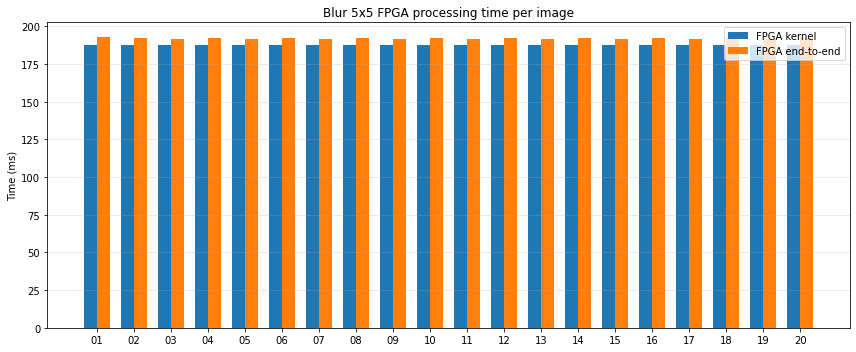


Blur 5x5 batch summary
Images processed:                 20
Total pixels processed:           8,192,000
FPGA kernel total time:           3754.675 ms
FPGA end-to-end total time:       3844.618 ms
Batch wall time:                  14s (13.734 s)
FPGA kernel mean per image:       187.734 ms
FPGA end-to-end mean per image:   192.231 ms
FPGA kernel throughput:           2.182 MPixels/s
FPGA end-to-end throughput:       2.131 MPixels/s
Temperature before/after:         nan C / nan C
CPU load before/after:            9.5% / 0.0%
RAM load before/after:            71.3% / 71.6%
Power before/after:               nan W / nan W
Energy, kernel time:              nan J
Energy, end-to-end time:          nan J
FPGA live load:                   N/A from runtime sensors
Per-image CSV:                    /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/blur5x5/blur5x5_per_image_results.csv
Summary CSV:                      /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/blur5x5/blur5x5

In [ ]:

# Cell 1: Blur 5x5 results on 20 images
# ---------------------------------------------------

try:
    blur_batch_result = run_kernel_on_batch("blur5x5")
except Exception:
    print("Blur batch run failed.")
    traceback.print_exc()
    blur_batch_result = None


Loaded 20 images from /home/xilinx/jupyter_notebooks/2_eissa/input
First image: 01.jpg (640, 640) uint8
Last image: 20.jpg (640, 640) uint8

FPGA batch run: Edge emphasis 5x5
Images: 20
Image size: 640x640
Output folder: /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/edge_emphasis5x5

Overlay files
BIT: /home/xilinx/jupyter_notebooks/2_eissa/conv2d_pynq_overlay.bit
HWH: /home/xilinx/jupyter_notebooks/2_eissa/conv2d_pynq_overlay.hwh
Loading overlay...
Overlay loaded.
Detected IP: conv2d_accel_0
Register names: ['CTRL', 'GIER', 'IP_IER', 'IP_ISR', 'img_in_1', 'img_in_2', 'img_out_1', 'img_out_2', 'rows', 'cols', 'divisor', 'bias', 'k00', 'k01', 'k02', 'k03', 'k04', 'k10', 'k11', 'k12', 'k13', 'k14', 'k20', 'k21', 'k22', 'k23', 'k24', 'k30', 'k31', 'k32', 'k33', 'k34', 'k40', 'k41', 'k42', 'k43', 'k44']
Using IP: conv2d_accel_0
before_edge_emphasis5x5: CPU=57.1% | RAM=343.8/491.7 MB (72.5%) | Process=105.8 MB | Load1=0.70 | Temp=nan C | Power=nan W
  Power sensor: not available.

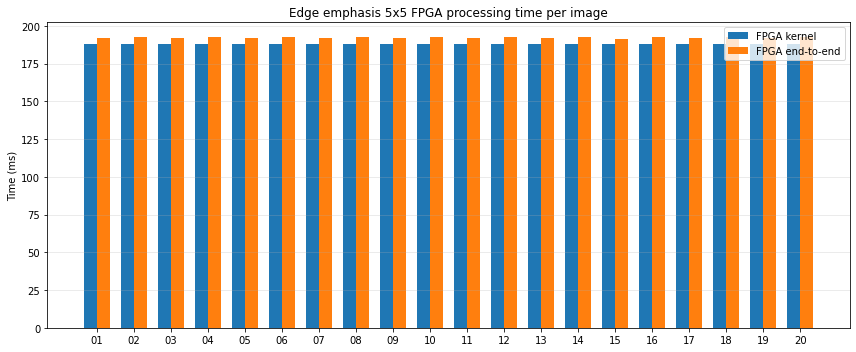


Edge emphasis 5x5 batch summary
Images processed:                 20
Total pixels processed:           8,192,000
FPGA kernel total time:           3754.573 ms
FPGA end-to-end total time:       3842.898 ms
Batch wall time:                  7s (6.560 s)
FPGA kernel mean per image:       187.729 ms
FPGA end-to-end mean per image:   192.145 ms
FPGA kernel throughput:           2.182 MPixels/s
FPGA end-to-end throughput:       2.132 MPixels/s
Temperature before/after:         nan C / nan C
CPU load before/after:            57.1% / 9.5%
RAM load before/after:            72.5% / 72.5%
Power before/after:               nan W / nan W
Energy, kernel time:              nan J
Energy, end-to-end time:          nan J
FPGA live load:                   N/A from runtime sensors
Per-image CSV:                    /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/edge_emphasis5x5/edge_emphasis5x5_per_image_results.csv
Summary CSV:                      /home/xilinx/jupyter_notebooks/2_eissa/fpga_on

In [ ]:

# Cell 2: Edge-emphasis 5x5 results on 20 images
# ---------------------------------------------------

try:
    edge_batch_result = run_kernel_on_batch("edge_emphasis5x5")
except Exception:
    print("Edge-emphasis batch run failed.")
    traceback.print_exc()
    edge_batch_result = None



Combined FPGA batch statistics
Saved combined CSV: /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/combined_fpga_batch_statistics.csv
Saved text summary: /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/combined_fpga_batch_summary.txt

Blur 5x5
--------
Images processed:               20
Total pixels:                   8,192,000
FPGA kernel total time:         3754.675 ms
FPGA end-to-end total time:     3844.618 ms
Batch wall time:                13.734 s
Kernel throughput:              2.182 MPixels/s
End-to-end throughput:          2.131 MPixels/s
Temperature before/after:       nan C / nan C
CPU load before/after:          9.5% / 0.0%
RAM load before/after:          71.3% / 71.6%
Average power:                  nan W
Energy end-to-end:              nan J
FPGA live load:                 N/A from standard runtime sensors

Edge emphasis 5x5
-----------------
Images processed:               20
Total pixels:                   8,192,000
FPGA kernel total time:         37

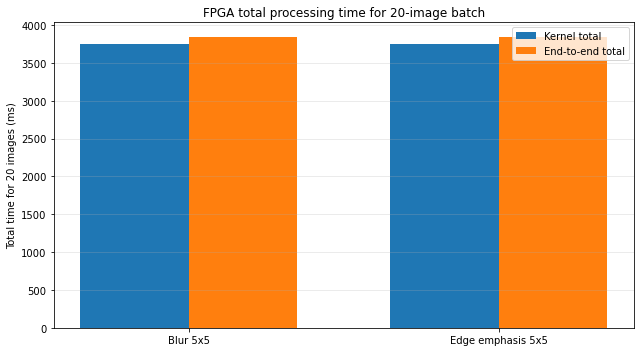

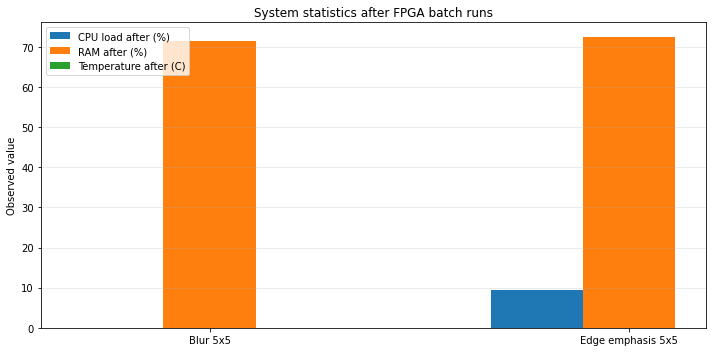

Saved timing chart: /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/combined_total_timing.png
Saved system stats chart: /home/xilinx/jupyter_notebooks/2_eissa/fpga_only_outputs/combined_system_statistics.png


In [ ]:

# Cell 3: Final combined statistics
# -----------------------------------------------

def save_combined_statistics() -> None:
    folder = notebook_folder()
    out_dir = folder / OUTPUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)

    results = [r for r in ALL_BATCH_RESULTS.values() if r is not None]
    if not results:
        print("No batch results found. Run the blur and edge-emphasis cells first.")
        return

    summary_rows = []
    for r in results:
        row = {k: v for k, v in r.items() if k != "per_image"}
        summary_rows.append(row)

    combined_csv = out_dir / "combined_fpga_batch_statistics.csv"
    with combined_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()))
        writer.writeheader()
        writer.writerows(summary_rows)

    # Text summary for report/presentation.
    summary_txt = out_dir / "combined_fpga_batch_summary.txt"
    with summary_txt.open("w", encoding="utf-8") as f:
        f.write("FPGA-only Conv2D batch performance summary\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Input set: {EXPECTED_IMAGE_COUNT} images from ./{INPUT_DIR_NAME}/\n")
        f.write(f"Image size: {EXPECTED_IMAGE_SIZE[0]}x{EXPECTED_IMAGE_SIZE[1]}\n")
        f.write(f"Overlay: {OVERLAY_BIT_FILENAME}\n\n")

        for r in results:
            f.write(f"{r['kernel_display']}\n")
            f.write("-" * 40 + "\n")
            f.write(f"Images processed: {r['image_count']}\n")
            f.write(f"Total pixels: {r['total_pixels']:,}\n")
            f.write(f"FPGA kernel total time: {r['fpga_kernel_total_ms']:.3f} ms\n")
            f.write(f"FPGA end-to-end total time: {r['fpga_end_to_end_total_ms']:.3f} ms\n")
            f.write(f"Wall time: {r['batch_wall_time_s']:.3f} s\n")
            f.write(f"Kernel throughput: {r['fpga_kernel_throughput_mpix_s']:.3f} MPixels/s\n")
            f.write(f"End-to-end throughput: {r['fpga_end_to_end_throughput_mpix_s']:.3f} MPixels/s\n")
            f.write(f"Temperature before/after: {r['temperature_before_c']:.1f} C / {r['temperature_after_c']:.1f} C\n")
            f.write(f"CPU load before/after: {r['cpu_load_before_percent']:.1f}% / {r['cpu_load_after_percent']:.1f}%\n")
            f.write(f"RAM load before/after: {r['ram_percent_before']:.1f}% / {r['ram_percent_after']:.1f}%\n")
            f.write(f"Average power: {r['average_power_w']:.6f} W\n")
            f.write(f"Energy end-to-end: {r['energy_end_to_end_j']:.6f} J\n")
            f.write(f"FPGA live load: {r['fpga_runtime_load_note']}\n")
            f.write(f"Power note: {r['power_note']}\n\n")

    print("\n" + "=" * 100)
    print("Combined FPGA batch statistics")
    print("=" * 100)
    print(f"Saved combined CSV: {combined_csv}")
    print(f"Saved text summary: {summary_txt}")

    for r in results:
        print("\n" + r["kernel_display"])
        print("-" * len(r["kernel_display"]))
        print(f"Images processed:               {r['image_count']}")
        print(f"Total pixels:                   {r['total_pixels']:,}")
        print(f"FPGA kernel total time:         {r['fpga_kernel_total_ms']:.3f} ms")
        print(f"FPGA end-to-end total time:     {r['fpga_end_to_end_total_ms']:.3f} ms")
        print(f"Batch wall time:                {r['batch_wall_time_s']:.3f} s")
        print(f"Kernel throughput:              {r['fpga_kernel_throughput_mpix_s']:.3f} MPixels/s")
        print(f"End-to-end throughput:          {r['fpga_end_to_end_throughput_mpix_s']:.3f} MPixels/s")
        print(f"Temperature before/after:       {r['temperature_before_c']:.1f} C / {r['temperature_after_c']:.1f} C")
        print(f"CPU load before/after:          {r['cpu_load_before_percent']:.1f}% / {r['cpu_load_after_percent']:.1f}%")
        print(f"RAM load before/after:          {r['ram_percent_before']:.1f}% / {r['ram_percent_after']:.1f}%")
        print(f"Average power:                  {r['average_power_w']:.6f} W")
        print(f"Energy end-to-end:              {r['energy_end_to_end_j']:.6f} J")
        print("FPGA live load:                 N/A from standard runtime sensors")

    # Combined timing chart.
    labels = [r["kernel_display"] for r in results]
    x = np.arange(len(results), dtype=np.float64)
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, [r["fpga_kernel_total_ms"] for r in results], width, label="Kernel total")
    plt.bar(x + width / 2, [r["fpga_end_to_end_total_ms"] for r in results], width, label="End-to-end total")
    plt.xticks(x, labels)
    plt.ylabel("Total time for 20 images (ms)")
    plt.title("FPGA total processing time for 20-image batch")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    chart_path = out_dir / "combined_total_timing.png"
    plt.savefig(chart_path, dpi=180)
    plt.show()

    # System statistics chart.
    plt.figure(figsize=(10, 5))
    x = np.arange(len(results), dtype=np.float64)
    width = 0.22
    plt.bar(x - width, [r["cpu_load_after_percent"] for r in results], width, label="CPU load after (%)")
    plt.bar(x, [r["ram_percent_after"] for r in results], width, label="RAM after (%)")
    plt.bar(x + width, [r["temperature_after_c"] for r in results], width, label="Temperature after (C)")
    plt.xticks(x, labels)
    plt.ylabel("Observed value")
    plt.title("System statistics after FPGA batch runs")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    stats_chart_path = out_dir / "combined_system_statistics.png"
    plt.savefig(stats_chart_path, dpi=180)
    plt.show()

    print(f"Saved timing chart: {chart_path}")
    print(f"Saved system stats chart: {stats_chart_path}")


save_combined_statistics()
